In [1]:
import matplotlib.pyplot as plt 
from astropy.io import fits 
import numpy as np 


In [43]:
obs = fits.open("/home/milic/data/scratch/mihi_data.fits")[0].data[15:-15, 15:-15,0,45:525]
obs.shape

(116, 130, 480)

In [46]:
fit = fits.open("test_inverted.fits")[1].data
fit.shape

(116, 130, 480)

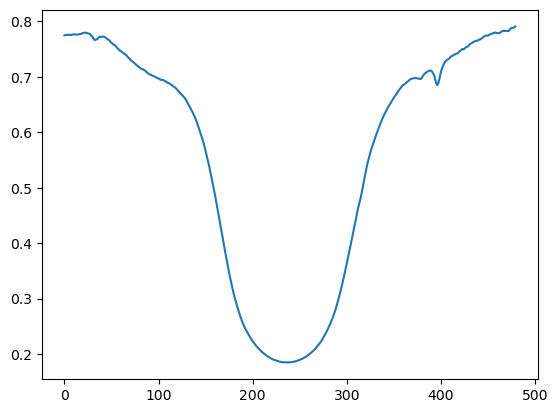

In [51]:
plt.plot(np.mean(obs,axis=(0,1)))

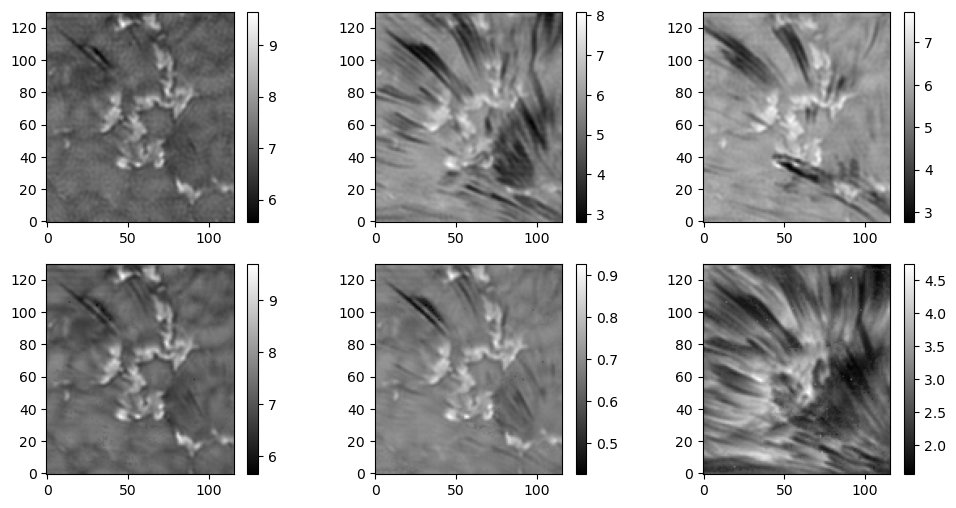

In [78]:
plt.figure(figsize=[12,6])
plt.subplot(231)
plt.imshow(np.sum(obs[:,:,80:90], axis=2).T, origin='lower', cmap = 'gray')
plt.colorbar()
plt.subplot(232)
plt.imshow(np.sum(obs[:,:,150:160], axis=2).T, origin='lower', cmap = 'gray')
plt.colorbar()
plt.subplot(233)
plt.imshow(np.sum(obs[:,:,320:330], axis=2).T, origin='lower', cmap = 'gray')
plt.colorbar()
plt.subplot(234)
plt.imshow(np.sum(fit[:,:,80:90], axis=2).T, origin='lower', cmap = 'gray')
plt.colorbar()
plt.subplot(235)
plt.imshow(np.sum(fit[:,:,120:121], axis=2).T, origin='lower', cmap = 'gray')
plt.colorbar()
plt.subplot(236)
plt.imshow(np.sum(fit[:,:,180:190], axis=2).T, origin='lower', cmap = 'gray')
plt.colorbar()

In [36]:
ll = fits.open("/home/milic/data/scratch/mihi_data.fits")[1].data[45:525]

In [60]:
chisq = np.sum((obs[:,:,100:120]-fit[:,:,100:120])**2.0 / 1E-4, axis=2) / 20

ValueError: operands could not be broadcast together with shapes (20,20,20) (116,130,20) 

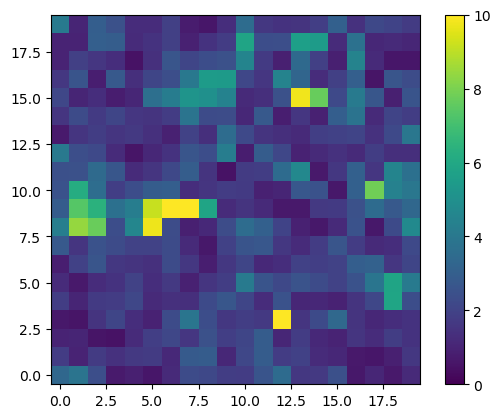

In [61]:
plt.imshow(chisq[60:80, 20:40].T, origin='lower',vmin=0, vmax=10)
plt.colorbar()

In [38]:
model = fits.open("test_inverted.fits")[0].data
model.shape

(116, 130, 11)

In [68]:
model[:,:,3] -= np.mean(model[:,:,3])
model[:,:,8] -= np.mean(model[:,:,3])

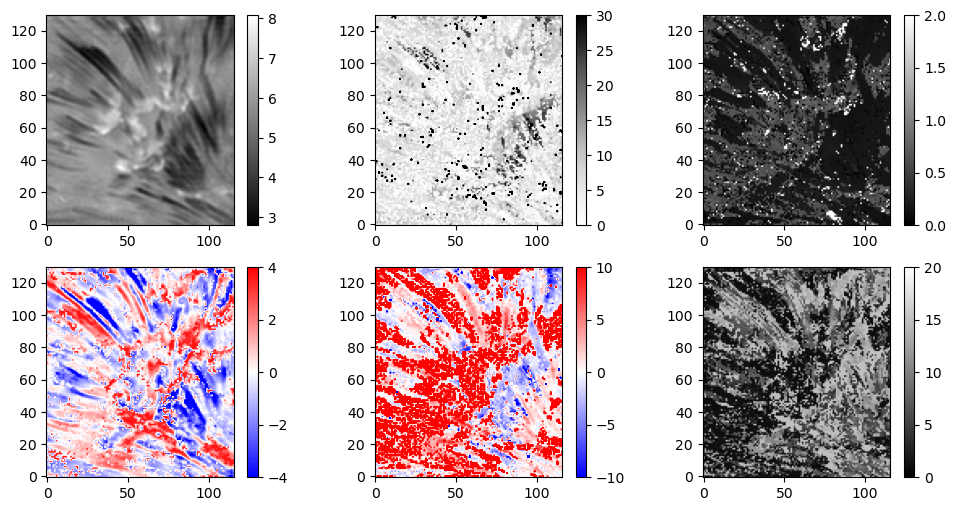

In [77]:
plt.figure(figsize=[12,6])
plt.subplot(231)
plt.imshow(np.sum(obs[:,:,150:160], axis=2).T, origin='lower', cmap = 'gray')
plt.colorbar()
plt.subplot(232)
plt.imshow(model[:,:,7].T, origin='lower', cmap = 'Grays', vmin=0, vmax=30)
plt.colorbar()
plt.subplot(233)
plt.imshow(model[:,:,6].T, origin='lower', cmap = 'gray', vmin=0, vmax=2)
plt.colorbar()
plt.subplot(234)
plt.imshow(model[:,:,3].T, origin='lower', cmap = 'bwr', vmin = -4, vmax=4)
plt.colorbar()
plt.subplot(235)
plt.imshow(model[:,:,8].T * model[:,:,7].T/10., origin='lower', cmap = 'bwr', vmin=-10, vmax=10)
plt.colorbar()
plt.subplot(236)
plt.imshow(model[:,:,9].T, origin='lower', cmap = 'gray', vmin=0,vmax=20)
plt.colorbar()




In [39]:
import cloud_model as cm 

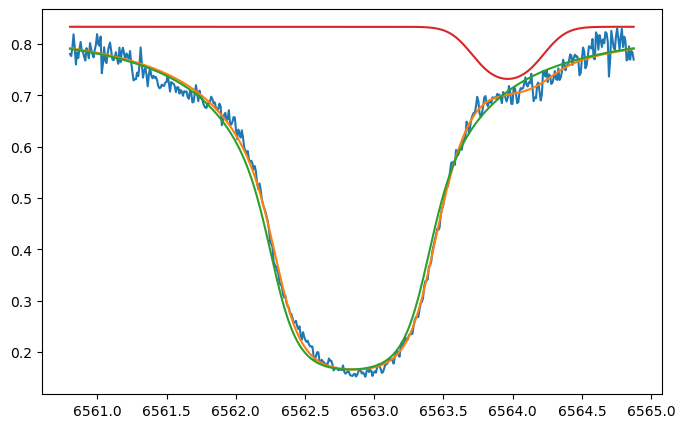

In [83]:
i = 20
j = 20
plt.figure(figsize=[8,5])
plt.plot(ll,obs_to_fit[i,j])
plt.plot(ll,fit[i,j])
plt.plot(ll,cm.me(model[i,j,0], model[i,j,1], model[i,j,2], model[i,j,3], model[i,j,4], model[i,j,5], 6562.8, ll))
plt.plot(ll,cm.cloud(model[i,j,6], model[i,j,7], model[i,j,8], model[i,j,9], model[i,j,10], 6562.8, ll, model[i,j,0] + model[i,j,1]))
plt.savefig("halpha.png", bbox_inches='tight')

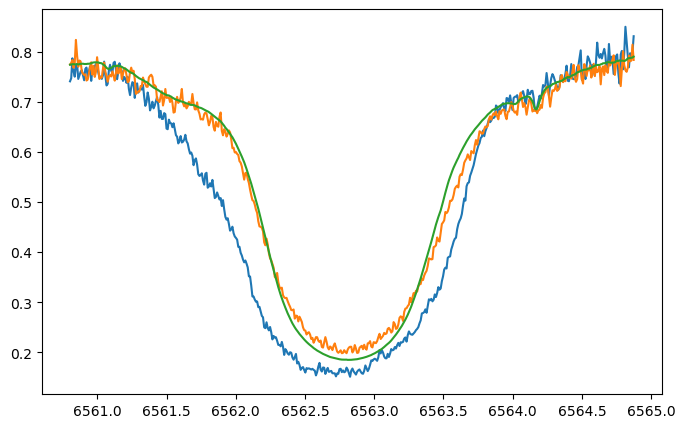

In [81]:
plt.figure(figsize=[8,5])
plt.plot(ll,obs_to_fit[30,100])
plt.plot(ll,obs_to_fit[55,100])
plt.plot(ll,np.mean(obs,axis=(0,1)))
